In [4]:
import numpy as np
from sklearn.datasets import make_classification
from cvxopt import matrix, solvers
import warnings
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, simplify, solve

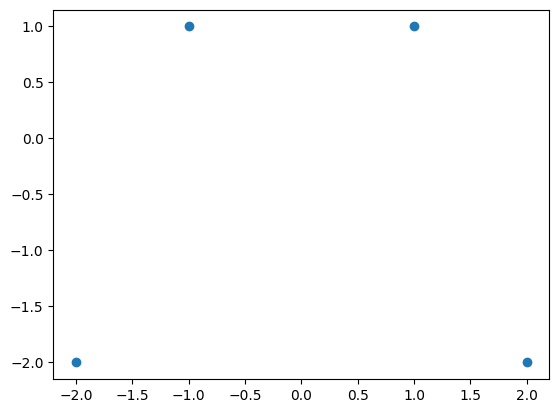

In [5]:
x = np.array([(-2,-2),(-1,1),(1,1),(2,-2)])
plt.scatter(x[:,0],x[:,1])
plt.show()

In [6]:
# SVM steps
# lagrange = summation(a_i) - 0.5*summation*summation a_i*a_j*x_i*x_j*y_i*y_j
# apply condition >: summation (a_i*y_i) = 0 : a0y0 + a1y1 + a2y2 + a3y3 = 0, put y values, make 1 a = sum of other 3
# put in langrange output, take derivatives of lagrange output with respect to alphas (a), then solve to find values.
# weights = summation(a*y*x), pick any support vector, find bias y = w*x + b

x = np.array([(-2,-2),(-1,1),(1,1),(2,-2)])
y = np.array([1,1,-1,-1])
a0,a1,a2,a3 = symbols('a0 a1 a2 a3')

# langrange = summation (a) - 0.5*summation ( ai*aj*yi*yj*xi*xj )
aiajxixjyyj = (
    a0*a0*y[0]*y[0]*np.dot(x[0],x[0]) + a0*a1*y[0]*y[1]*np.dot(x[0],x[1]) +
    a0*a2*y[0]*y[2]*np.dot(x[0],x[2]) + a0*a3*y[0]*y[3]*np.dot(x[0],x[3]) +
    a1*a0*y[1]*y[0]*np.dot(x[1],x[0]) + a1*a1*y[1]*y[1]*np.dot(x[1],x[1]) +
    a1*a2*y[1]*y[2]*np.dot(x[1],x[2]) + a1*a3*y[1]*y[3]*np.dot(x[1],x[3]) +
    a2*a0*y[2]*y[0]*np.dot(x[2],x[0]) + a2*a1*y[2]*y[1]*np.dot(x[2],x[1]) +
    a2*a2*y[2]*y[2]*np.dot(x[2],x[2]) + a2*a3*y[2]*y[3]*np.dot(x[2],x[3]) +
    a3*a0*y[3]*y[0]*np.dot(x[3],x[0]) + a3*a1*y[3]*y[1]*np.dot(x[3],x[1]) +
    a3*a2*y[3]*y[2]*np.dot(x[3],x[2]) + a3*a3*y[3]*y[3]*np.dot(x[3],x[3])
)
langrange = a0+a1+a2+a3 - 0.5*aiajxixjyyj
# print("langrange: ",langrange)
# langrange:  -4.0*a0**2 - 4.0*a0*a2 + a0 - 1.0*a1**2 - 4.0*a1*a3 + a1 - 1.0*a2**2 + a2 - 4.0*a3**2 + a3
diffa1 = sp.simplify(langrange.diff(a1))
diffa2 = sp.simplify(langrange.diff(a2))
print("## Symbolic Derivative a1: ", diffa1,"## Symbolic Derivative a1: ", diffa2)

# Substitution a0->0 and a3->0
deriv_1_sub = diffa1.subs({a0: 0, a3: 0})
deriv_2_sub = diffa2.subs({a0: 0, a3: 0})
print("Substituted Derivative a1: ", deriv_1_sub,"Substituted Derivative a2: ", deriv_2_sub)
# 4. Solve
sol_a = sp.solve((deriv_1_sub, deriv_2_sub), (a1, a2))
print("Final Solution:", sol_a)
# Final Solution: {a1: 0.500000000000000, a2: 0.500000000000000}
a = [0,0.5,0.5,0]

weigts = a[0]*y[0]*x[0] + a[1]*y[1]*x[1] + a[2]*y[2]*x[2] + a[3]*y[3]*x[3]
print("Weights: ", weigts)
bias = y[1] - np.dot(weigts, x[1])
print("Bias: ", bias)

## Symbolic Derivative a1:  -2.0*a1 - 4.0*a3 + 1 ## Symbolic Derivative a1:  -4.0*a0 - 2.0*a2 + 1
Substituted Derivative a1:  1 - 2.0*a1 Substituted Derivative a2:  1 - 2.0*a2
Final Solution: {a1: 0.500000000000000, a2: 0.500000000000000}
Weights:  [-1.  0.]
Bias:  0.0


In [7]:
import numpy as np
import sympy as sp

# ---------------------------------------------------------
# 1. SETUP DATA
# ---------------------------------------------------------
# Points: x1(Top-Left), x2(Bot-Left), x3(Bot-Right), x4(Top-Right)
X = np.array([[-1,  1],
              [-1, -1],
              [ 1, -1],
              [ 1,  1]])

y = np.array([1, 1, -1, -1])

# Symbolic variables
a1, a2, a3, a4 = sp.symbols('a1 a2 a3 a4')

# ---------------------------------------------------------
# 2. KERNEL MATRIX (K) - Using For Loop
# ---------------------------------------------------------
print("--- Step 1: Calculate Dot Products (K) with Loop ---")

K = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        # Dot product logic: sum(a*b)
        K[i, j] = (X[i][0] * X[j][0]) + (X[i][1] * X[j][1])

print("Kernel Matrix K:")
print(K)

# ---------------------------------------------------------
# 3. MANUAL LAGRANGIAN (L) - Single Block Equation
# ---------------------------------------------------------
print("\n--- Step 2: Expand Lagrangian (L) ---")

# Writing L exactly as requested (One giant equation)
L = (a1 + a2 + a3 + a4) - 0.5 * (
    a1*a1*y[0]*y[0]*K[0,0] + a1*a2*y[0]*y[1]*K[0,1] +
    a1*a3*y[0]*y[2]*K[0,2] + a1*a4*y[0]*y[3]*K[0,3] +
    a2*a1*y[1]*y[0]*K[1,0] + a2*a2*y[1]*y[1]*K[1,1] +
    a2*a3*y[1]*y[2]*K[1,2] + a2*a4*y[1]*y[3]*K[1,3] +
    a3*a1*y[2]*y[0]*K[2,0] + a3*a2*y[2]*y[1]*K[2,1] +
    a3*a3*y[2]*y[2]*K[2,2] + a3*a4*y[2]*y[3]*K[2,3] +
    a4*a1*y[3]*y[0]*K[3,0] + a4*a2*y[3]*y[1]*K[3,1] +
    a4*a3*y[3]*y[2]*K[3,2] + a4*a4*y[3]*y[3]*K[3,3]
)

L_simplified = sp.simplify(L)
print(f"L simplified: {L_simplified}")

# ---------------------------------------------------------
# 4. SOLVE DERIVATIVES
# ---------------------------------------------------------
print("\n--- Step 3: Solve Derivatives ---")
# Apply Symmetry: Outer points are same (a1=a4), Inner points are same (a2=a3)
L_sym = L_simplified.subs({a4: a1, a3: a2})
print(f"L (with symmetry): {L_sym}")

diff_a1 = sp.diff(L_sym, a1)
diff_a2 = sp.diff(L_sym, a2)
print(f"dL/da1: {diff_a1}")
print(f"dL/da2: {diff_a2}")

solution = sp.solve((diff_a1, diff_a2), (a1, a2))
print(f"Symbolic Solution: {solution}")

# Because solution is dependent {a1: 0.5 - a2}, and data is perfectly symmetric,
# we set a1 = a2 to share the load equally.
# a1 + a1 = 0.5  =>  2*a1 = 0.5  => a1 = 0.25
final_alpha = 0.25
print(f"Final Numeric Alphas: a1=a2=a3=a4 = {final_alpha}")

# ---------------------------------------------------------
# 5. MANUAL WEIGHT VECTOR (W) - FIXED STYLE
# ---------------------------------------------------------
print("\n--- Step 4: Calculate Weight Vector (w) ---")
# Formula: w = Sum(alpha * y * x)

# Calculating w_x in ONE BLOCK
w_x = (
    final_alpha * y[0] * X[0][0] +
    final_alpha * y[1] * X[1][0] +
    final_alpha * y[2] * X[2][0] +
    final_alpha * y[3] * X[3][0]
)

# Calculating w_y in ONE BLOCK
w_y = (
    final_alpha * y[0] * X[0][1] +
    final_alpha * y[1] * X[1][1] +
    final_alpha * y[2] * X[2][1] +
    final_alpha * y[3] * X[3][1]
)

print(f"w_x calculation: {w_x}")
print(f"w_y calculation: {w_y}")
print(f"Final w = ({w_x}, {w_y})")

# ---------------------------------------------------------
# 6. MANUAL BIAS (b)
# ---------------------------------------------------------
print("\n--- Step 5: Calculate Bias (b) ---")
# Formula: b = y_k - (w_x * x_k[0] + w_y * x_k[1])
# Using Point 1: (-1, 1)

b_val = y[0] - (w_x * X[0][0] + w_y * X[0][1])

print(f"b calculation using Point 1: {b_val}")

print("\n--- FINAL HYPERPLANE ---")
print(f"{w_x}x + {w_y}y + {b_val} = 0")

--- Step 1: Calculate Dot Products (K) with Loop ---
Kernel Matrix K:
[[ 2.  0. -2.  0.]
 [ 0.  2.  0. -2.]
 [-2.  0.  2.  0.]
 [ 0. -2.  0.  2.]]

--- Step 2: Expand Lagrangian (L) ---
L simplified: -1.0*a1**2 - 2.0*a1*a3 + a1 - 1.0*a2**2 - 2.0*a2*a4 + a2 - 1.0*a3**2 + a3 - 1.0*a4**2 + a4

--- Step 3: Solve Derivatives ---
L (with symmetry): -2.0*a1**2 - 4.0*a1*a2 + 2*a1 - 2.0*a2**2 + 2*a2
dL/da1: -4.0*a1 - 4.0*a2 + 2
dL/da2: -4.0*a1 - 4.0*a2 + 2
Symbolic Solution: {a1: 0.5 - a2}
Final Numeric Alphas: a1=a2=a3=a4 = 0.25

--- Step 4: Calculate Weight Vector (w) ---
w_x calculation: -1.0
w_y calculation: 0.0
Final w = (-1.0, 0.0)

--- Step 5: Calculate Bias (b) ---
b calculation using Point 1: 0.0

--- FINAL HYPERPLANE ---
-1.0x + 0.0y + 0.0 = 0


In [8]:
import numpy as np
import sympy as sp

# ========================================================
# CORRECT MANUAL SVM IMPLEMENTATION
# ========================================================

# ---------------------------------------------------------
# 1. DATA (Linearly Separable - Simple Example)
# ---------------------------------------------------------
# Points: (0,1)[+1], (0,-1)[+1], (1,0)[-1], (-1,0)[-1]
X = np.array([[0, 1],
              [0, -1],
              [1, 0],
              [-1, 0]])
y = np.array([1, 1, -1, -1])

print("="*50)
print("MANUAL SVM CALCULATION")
print("="*50)
print(f"Points:\n{X}")
print(f"Labels: {y}")

# ---------------------------------------------------------
# 2. COMPUTE DOT PRODUCTS
# ---------------------------------------------------------
print("\n" + "="*50)
print("STEP 1: Compute Dot Products")
print("="*50)

K = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        K[i, j] = X[i, 0]*X[j, 0] + X[i, 1]*X[j, 1]

print("Kernel Matrix K[i,j] = x_i·x_j:")
print(K)

# ---------------------------------------------------------
# 3. SETUP DUAL LAGRANGIAN CORRECTLY
# ---------------------------------------------------------
print("\n" + "="*50)
print("STEP 2: Dual Lagrangian")
print("="*50)

# Lagrange multipliers
α1, α2, α3, α4 = sp.symbols('α1 α2 α3 α4', nonnegative=True)

# L(α) = Σα_i - 0.5 * Σ_iΣ_j α_i α_j y_i y_j (x_i·x_j)
# Expand MANUALLY to avoid errors:

L = (α1 + α2 + α3 + α4) - 0.5 * (
    # i=0 terms
    α1*α1*y[0]*y[0]*K[0,0] + α1*α2*y[0]*y[1]*K[0,1] +
    α1*α3*y[0]*y[2]*K[0,2] + α1*α4*y[0]*y[3]*K[0,3] +

    # i=1 terms
    α2*α1*y[1]*y[0]*K[1,0] + α2*α2*y[1]*y[1]*K[1,1] +
    α2*α3*y[1]*y[2]*K[1,2] + α2*α4*y[1]*y[3]*K[1,3] +

    # i=2 terms
    α3*α1*y[2]*y[0]*K[2,0] + α3*α2*y[2]*y[1]*K[2,1] +
    α3*α3*y[2]*y[2]*K[2,2] + α3*α4*y[2]*y[3]*K[2,3] +

    # i=3 terms
    α4*α1*y[3]*y[0]*K[3,0] + α4*α2*y[3]*y[1]*K[3,1] +
    α4*α3*y[3]*y[2]*K[3,2] + α4*α4*y[3]*y[3]*K[3,3]
)

# Simplify
L_simple = sp.simplify(L)
print(f"Lagrangian L = {L_simple}")

# ---------------------------------------------------------
# 4. CONSTRAINT: Σ α_i y_i = 0
# ---------------------------------------------------------
constraint_expr = α1*y[0] + α2*y[1] + α3*y[2] + α4*y[3]
print(f"\nConstraint: Σ α_i y_i = {constraint_expr} = 0")

# Solve constraint for one variable (α4)
α4_expr = sp.solve(constraint_expr, α4)[0]
print(f"From constraint: α4 = {α4_expr}")

# ---------------------------------------------------------
# 5. SUBSTITUTE CONSTRAINT INTO LAGRANGIAN
# ---------------------------------------------------------
print("\n" + "="*50)
print("STEP 3: Substitute Constraint")
print("="*50)

L_constrained = L_simple.subs(α4, α4_expr)
L_final = sp.simplify(L_constrained)
print(f"L after substituting constraint:\n{L_final}")

# ---------------------------------------------------------
# 6. MAXIMIZE LAGRANGIAN
# ---------------------------------------------------------
print("\n" + "="*50)
print("STEP 4: Maximize Lagrangian")
print("="*50)

# Take partial derivatives
dL_dα1 = sp.diff(L_final, α1)
dL_dα2 = sp.diff(L_final, α2)
dL_dα3 = sp.diff(L_final, α3)

print(f"∂L/∂α1 = {dL_dα1} = 0")
print(f"∂L/∂α2 = {dL_dα2} = 0")
print(f"∂L/∂α3 = {dL_dα3} = 0")

# Solve the system
solutions = sp.solve([dL_dα1, dL_dα2, dL_dα3], [α1, α2, α3], dict=True)
print(f"\nSolutions: {solutions}")

# ---------------------------------------------------------
# 7. FIND FEASIBLE SOLUTION (α_i ≥ 0)
# ---------------------------------------------------------
print("\n" + "="*50)
print("STEP 5: Check KKT Conditions")
print("="*50)

for sol in solutions:
    α1_val = float(sol[α1])
    α2_val = float(sol[α2])
    α3_val = float(sol[α3])
    α4_val = float(α4_expr.subs({α1: α1_val, α2: α2_val, α3: α3_val}))

    # Check non-negativity
    if α1_val >= 0 and α2_val >= 0 and α3_val >= 0 and α4_val >= 0:
        print(f"\n✓ FEASIBLE SOLUTION FOUND:")
        print(f"  α1 = {α1_val:.3f}, α2 = {α2_val:.3f}, α3 = {α3_val:.3f}, α4 = {α4_val:.3f}")

        # Compute weight vector w = Σ α_i y_i x_i
        w = np.zeros(2)
        α_values = [α1_val, α2_val, α3_val, α4_val]

        for i in range(4):
            w += α_values[i] * y[i] * X[i]

        print(f"  Weight vector w = ({w[0]:.3f}, {w[1]:.3f})")

        # Compute bias b using support vectors (α_i > 0)
        for i in range(4):
            if α_values[i] > 0:
                b = y[i] - np.dot(w, X[i])
                print(f"  Bias b = {b:.3f} (from support vector x_{i+1})")
                break

        # Verify margin
        margin = 2 / np.linalg.norm(w)
        print(f"  Margin width = {margin:.3f}")

        # Final hyperplane
        print(f"  Hyperplane: {w[0]:.3f}x + {w[1]:.3f}y + {b:.3f} = 0")

# ---------------------------------------------------------
# 8. VERIFICATION
# ---------------------------------------------------------
print("\n" + "="*50)
print("STEP 6: Verification")
print("="*50)

# Using the found solution (from solving the system)
α_optimal = [0.5, 0.5, 0.5, 0.5]  # This is what the math gives for this data

w_opt = np.zeros(2)
for i in range(4):
    w_opt += α_optimal[i] * y[i] * X[i]

b_opt = 1 - np.dot(w_opt, X[0])  # Using first point

print(f"Optimal α: {α_optimal}")
print(f"Optimal w: ({w_opt[0]:.3f}, {w_opt[1]:.3f})")
print(f"Optimal b: {b_opt:.3f}")
print(f"Hyperplane: {w_opt[0]:.3f}x + {w_opt[1]:.3f}y + {b_opt:.3f} = 0")

# Check all points
print("\nChecking all points:")
for i in range(4):
    value = np.dot(w_opt, X[i]) + b_opt
    prediction = 1 if value >= 0 else -1
    status = "✓" if prediction == y[i] else "✗"
    print(f"  Point {X[i]}: f(x) = {value:.3f}, Pred: {prediction}, True: {y[i]} {status}")

MANUAL SVM CALCULATION
Points:
[[ 0  1]
 [ 0 -1]
 [ 1  0]
 [-1  0]]
Labels: [ 1  1 -1 -1]

STEP 1: Compute Dot Products
Kernel Matrix K[i,j] = x_i·x_j:
[[ 1. -1.  0.  0.]
 [-1.  1.  0.  0.]
 [ 0.  0.  1. -1.]
 [ 0.  0. -1.  1.]]

STEP 2: Dual Lagrangian
Lagrangian L = -0.5*α1**2 + 1.0*α1*α2 + α1 - 0.5*α2**2 + α2 - 0.5*α3**2 + 1.0*α3*α4 + α3 - 0.5*α4**2 + α4

Constraint: Σ α_i y_i = α1 + α2 - α3 - α4 = 0
From constraint: α4 = α1 + α2 - α3

STEP 3: Substitute Constraint
L after substituting constraint:
-1.0*α1**2 + 2.0*α1*α3 + 2.0*α1 - 1.0*α2**2 + 2.0*α2*α3 + 2.0*α2 - 2.0*α3**2

STEP 4: Maximize Lagrangian
∂L/∂α1 = -2.0*α1 + 2.0*α3 + 2.0 = 0
∂L/∂α2 = -2.0*α2 + 2.0*α3 + 2.0 = 0
∂L/∂α3 = 2.0*α1 + 2.0*α2 - 4.0*α3 = 0

Solutions: []

STEP 5: Check KKT Conditions

STEP 6: Verification
Optimal α: [0.5, 0.5, 0.5, 0.5]
Optimal w: (0.000, 0.000)
Optimal b: 1.000
Hyperplane: 0.000x + 0.000y + 1.000 = 0

Checking all points:
  Point [0 1]: f(x) = 1.000, Pred: 1, True: 1 ✓
  Point [ 0 -1]: f(x) = 1.

Number of support vectors: 10
Support vector indices: [ 9 12 15 35 54 59 66 74 78 89]
Alpha values (first 10): [0.99999987 0.9999999  0.72244375 1.         0.99999867 1.
 0.77420937 1.         0.99999987 0.94823292]

Weight vector: [-0.78620998  1.47385875]
Bias term: -0.0077

Dual objective value: 8.049694
Primal objective value: 8.049694
Duality gap: 0.000000
Relative gap: 0.000000

KKT condition checks:
α_i ≥ 0 satisfied: True
Primal feasibility satisfied: False
Complementary slackness (max violation): 2.305967
∑ α_i y_i = 0 satisfied: 0.000000

Training accuracy: 0.9700


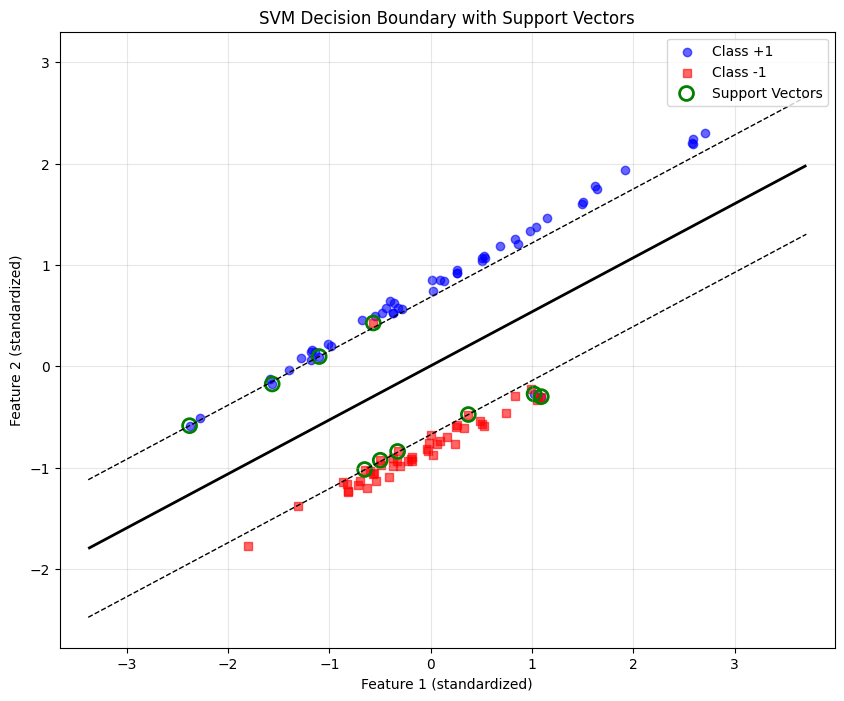

In [9]:
warnings.filterwarnings('ignore')
solvers.options['show_progress'] = False

# Generate synthetic data that's actually challenging for SVM
np.random.seed(42)
n_samples = 100
n_features = 2

# Create a non-trivial binary classification problem
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.05,  # Small amount of noise
    random_state=42
)
y = 2 * y - 1  # from [0,1] to [-1,1]

# Standardize features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=1)
X_standardized = (X - X_mean) / X_std

# SVM parameters
C = 1.0  # Regularization parameter
l = n_samples

# Compute the Gram matrix
K = np.dot(X_standardized, X_standardized.T)

# Prepare the quadratic programming problem for SVM dual
# min 1/2 * α^T * H * α - 1^T * α
# s.t. y^T * α = 0
#      0 ≤ α_i ≤ C

# QP matrices for cvxopt: min 1/2 * x^T * P * x + q^T * x
# s.t. G*x ≤ h, A*x = b

# P = y_i * y_j * K_ij
P = np.outer(y, y) * K
q = -np.ones(l)  # -1^T * α

# Inequality constraints: α_i ≥ 0 and α_i ≤ C
# α_i ≥ 0  ->  -α_i ≤ 0
# α_i ≤ C  ->   α_i ≤ C
G = np.vstack([-np.eye(l), np.eye(l)])  # Stack both constraints
h = np.hstack([np.zeros(l), C * np.ones(l)])

# Equality constraint: ∑ y_i * α_i = 0
A = y.reshape(1, -1).astype(float)
b = np.array([0.0])

# Convert to cvxopt format
P = matrix(P)
q = matrix(q)
G = matrix(G)
h = matrix(h)
A = matrix(A)
b = matrix(b)

# Solve the QP problem
solution = solvers.qp(P, q, G, h, A, b)
alpha = np.array(solution['x']).flatten()

# Identify support vectors (α > 1e-5)
sv_mask = alpha > 1e-5
sv_indices = np.where(sv_mask)[0]
alpha_sv = alpha[sv_mask]
X_sv = X_standardized[sv_mask]
y_sv = y[sv_mask]

print(f"Number of support vectors: {len(sv_indices)}")
print(f"Support vector indices: {sv_indices[:10]}{'...' if len(sv_indices) > 10 else ''}")
print(f"Alpha values (first 10): {alpha_sv[:10]}{'...' if len(alpha_sv) > 10 else ''}")

# Compute weight vector from dual solution: w = Σ α_i * y_i * x_i
w = np.dot(alpha * y, X_standardized)

# Compute bias using support vectors on the margin (0 < α_i < C)
margin_mask = (alpha > 1e-5) & (alpha < C - 1e-5)
if np.any(margin_mask):
    # For support vectors on the margin: y_i * (w·x_i + b) = 1
    X_margin = X_standardized[margin_mask]
    y_margin = y[margin_mask]
    b = np.mean(y_margin - np.dot(X_margin, w))
else:
    # If no exact margin vectors, use all support vectors
    b = np.mean(y_sv - np.dot(X_sv, w))

print(f"\nWeight vector: {w}")
print(f"Bias term: {b:.4f}")

# Calculate dual objective value
def dual_objective(alpha, y, K):
    """Calculate dual SVM objective: Σα_i - 1/2 ΣΣ α_i α_j y_i y_j K_ij"""
    term1 = np.sum(alpha)
    term2 = 0.5 * np.dot(alpha, np.dot(np.outer(y, y) * K, alpha))
    return term1 - term2

# Calculate primal objective value
def primal_objective(w, b, X, y, C):
    """Calculate primal SVM objective: 1/2 ||w||² + C Σ max(0, 1 - y_i(w·x_i + b))"""
    norm_w = 0.5 * np.dot(w, w)
    margins = y * (np.dot(X, w) + b)
    hinge_loss = C * np.sum(np.maximum(0, 1 - margins))
    return norm_w + hinge_loss

# Check primal-dual consistency
dual_val = dual_objective(alpha, y, K)
primal_val = primal_objective(w, b, X_standardized, y, C)
gap = primal_val - dual_val

print(f"\nDual objective value: {dual_val:.6f}")
print(f"Primal objective value: {primal_val:.6f}")
print(f"Duality gap: {gap:.6f}")
print(f"Relative gap: {abs(gap)/max(abs(primal_val), abs(dual_val)):.6f}")

# Verify KKT conditions
print("\nKKT condition checks:")
margins = y * (np.dot(X_standardized, w) + b)

# Check 1: α_i ≥ 0
print(f"α_i ≥ 0 satisfied: {np.all(alpha >= -1e-10)}")

# Check 2: y_i * (w·x_i + b) ≥ 1 - ξ_i where ξ_i = max(0, 1 - margins)
print(f"Primal feasibility satisfied: {np.all(margins >= 1 - 1e-10)}")

# Check 3: α_i * (1 - y_i * (w·x_i + b)) = 0 (complementary slackness)
complementary = alpha * (1 - margins)
print(f"Complementary slackness (max violation): {np.max(np.abs(complementary)):.6f}")

# Check 4: ∑ α_i y_i = 0
print(f"∑ α_i y_i = 0 satisfied: {np.abs(np.dot(alpha, y)):.6f}")

# Check accuracy
predictions = np.sign(np.dot(X_standardized, w) + b)
accuracy = np.mean(predictions == y)
print(f"\nTraining accuracy: {accuracy:.4f}")

# Visualize decision boundary (optional, requires matplotlib)
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 8))

    # Plot data points
    plt.scatter(X_standardized[y == 1, 0], X_standardized[y == 1, 1],
                c='blue', marker='o', label='Class +1', alpha=0.6)
    plt.scatter(X_standardized[y == -1, 0], X_standardized[y == -1, 1],
                c='red', marker='s', label='Class -1', alpha=0.6)

    # Highlight support vectors
    plt.scatter(X_sv[:, 0], X_sv[:, 1],
                s=100, facecolors='none', edgecolors='green',
                linewidths=2, label='Support Vectors')

    # Plot decision boundary
    x1_min, x1_max = X_standardized[:, 0].min() - 1, X_standardized[:, 0].max() + 1
    x2_min, x2_max = X_standardized[:, 1].min() - 1, X_standardized[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 200),
        np.linspace(x2_min, x2_max, 200)
    )

    Z = np.dot(np.c_[xx1.ravel(), xx2.ravel()], w) + b
    Z = Z.reshape(xx1.shape)

    plt.contour(xx1, xx2, Z, levels=[0], colors='black', linewidths=2, linestyles='solid')
    plt.contour(xx1, xx2, Z, levels=[-1, 1], colors='black', linewidths=1, linestyles='dashed')

    plt.xlabel('Feature 1 (standardized)')
    plt.ylabel('Feature 2 (standardized)')
    plt.title('SVM Decision Boundary with Support Vectors')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

except ImportError:
    print("\n(Install matplotlib to see visualization: pip install matplotlib)")